In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("orders_raw.csv")
p = pd.read_csv("products.csv")

print(df.head())
print(p.head())

   order_id  order_date customer_name       city              category  \
0         1  2026-03-09           Dev       Pune    Snacks & Beverages   
1         2  2026-05-22         Ayaan  Bengaluru    Snacks & Beverages   
2         3  2026-06-30          Yash  Bengaluru  Household Essentials   
3         4  2026-03-01         Sneha  Hyderabad    Snacks & Beverages   
4         5  2026-04-05         Rohit     Mumbai    Snacks & Beverages   

   product_id  quantity  amount_inr payment_mode     status  rating  
0          13         5       175.0          UPI  Delivered     5.0  
1          15         1        60.0   Debit Card  Delivered     5.0  
2          25         2       150.0          UPI  Delivered     2.0  
3          11         1        30.0          UPI  Delivered     4.0  
4          14         2       220.0   Debit Card  Delivered     3.0  
   product_id   product_name             category             supplier  \
0           1     Banana 1kg  Fruits & Vegetables        Fres

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    str    
 2   customer_name  508 non-null    str    
 3   city           508 non-null    str    
 4   category       508 non-null    str    
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    str    
 9   status         508 non-null    str    
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), str(6)
memory usage: 43.8 KB


In [3]:
print(df.describe())

         order_id  product_id    quantity   amount_inr      rating
count  508.000000  508.000000  508.000000   498.000000  439.000000
mean   250.204724   15.476378    3.045276   257.530120    3.082005
std    144.594139    8.747467    1.364497   559.424136    1.364126
min      1.000000    1.000000    1.000000    20.000000    1.000000
25%    125.750000    8.000000    2.000000    90.000000    2.000000
50%    249.500000   15.000000    3.000000   168.000000    3.000000
75%    376.250000   23.000000    4.000000   283.750000    4.000000
max    500.000000   30.000000    5.000000  7600.000000    5.000000


In [4]:
print(df["status"].value_counts())

status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64


In [5]:
print("Rows before removing duplicates:", len(df))

dup = df.duplicated("order_id").sum()
print("Duplicate order_id rows:", dup)

df = df.drop_duplicates("order_id", keep="first")

print("Rows after removing duplicates:", len(df))

Rows before removing duplicates: 508
Duplicate order_id rows: 8
Rows after removing duplicates: 500


In [6]:
df["city"] = df["city"].str.strip().str.title()
df["category"] = df["category"].str.strip().str.title()

print("Cities:")
print(df["city"].unique())

print("Categories:")
print(df["category"].unique())

Cities:
<StringArray>
['Pune', 'Bengaluru', 'Hyderabad', 'Mumbai']
Length: 4, dtype: str
Categories:
<StringArray>
[  'Snacks & Beverages', 'Household Essentials',               'Bakery',
        'Personal Care',  'Fruits & Vegetables',         'Dairy & Eggs']
Length: 6, dtype: str


In [7]:
print("Missing amount_inr:", df["amount_inr"].isnull().sum())
print("Missing rating:", df["rating"].isnull().sum())

Missing amount_inr: 10
Missing rating: 66


In [8]:
d = df[(df["status"] == "Delivered") & (df["amount_inr"].notna())].copy()

q1 = d["amount_inr"].quantile(0.25)
q3 = d["amount_inr"].quantile(0.75)

iqr = q3 - q1
upper = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Upper fence:", upper)

Q1: 90.0
Q3: 275.0
IQR: 185.0
Upper fence: 552.5


In [9]:
cap_count = (d["amount_inr"] > upper).sum()

print("Rows to be capped:", cap_count)

Rows to be capped: 16


In [10]:
df["amount_inr"] = df["amount_inr"].clip(upper=upper)

print("Maximum amount after capping:", df["amount_inr"].max())

Maximum amount after capping: 552.5


In [11]:
df["order_date"] = pd.to_datetime(df["order_date"])

df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()

df["revenue_per_unit"] = df["amount_inr"] / df["quantity"]

df["is_delivered"] = df["status"] == "Delivered"

print(df.head())

   order_id order_date customer_name       city              category  \
0         1 2026-03-09           Dev       Pune    Snacks & Beverages   
1         2 2026-05-22         Ayaan  Bengaluru    Snacks & Beverages   
2         3 2026-06-30          Yash  Bengaluru  Household Essentials   
3         4 2026-03-01         Sneha  Hyderabad    Snacks & Beverages   
4         5 2026-04-05         Rohit     Mumbai    Snacks & Beverages   

   product_id  quantity  amount_inr payment_mode     status  rating  month  \
0          13         5       175.0          UPI  Delivered     5.0      3   
1          15         1        60.0   Debit Card  Delivered     5.0      5   
2          25         2       150.0          UPI  Delivered     2.0      6   
3          11         1        30.0          UPI  Delivered     4.0      3   
4          14         2       220.0   Debit Card  Delivered     3.0      4   

  month_name  revenue_per_unit  is_delivered  
0      March              35.0          True 

In [12]:
cat = df[
    (df["status"] == "Delivered") &
    (df["amount_inr"].notna())
].groupby("category")["amount_inr"].sum().sort_values(ascending=False)

print(cat)

print("Top category:", cat.index[0])
print("Top category revenue:", cat.iloc[0])

category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr, dtype: float64
Top category: Household Essentials
Top category revenue: 20910.0


In [13]:
df = df.merge(p, on="product_id", how="left")

print(df.head())
print(df.columns)

print("Missing suppliers:", df["supplier"].isnull().sum())

   order_id order_date customer_name       city            category_x  \
0         1 2026-03-09           Dev       Pune    Snacks & Beverages   
1         2 2026-05-22         Ayaan  Bengaluru    Snacks & Beverages   
2         3 2026-06-30          Yash  Bengaluru  Household Essentials   
3         4 2026-03-01         Sneha  Hyderabad    Snacks & Beverages   
4         5 2026-04-05         Rohit     Mumbai    Snacks & Beverages   

   product_id  quantity  amount_inr payment_mode     status  rating  month  \
0          13         5       175.0          UPI  Delivered     5.0      3   
1          15         1        60.0   Debit Card  Delivered     5.0      5   
2          25         2       150.0          UPI  Delivered     2.0      6   
3          11         1        30.0          UPI  Delivered     4.0      3   
4          14         2       220.0   Debit Card  Delivered     3.0      4   

  month_name  revenue_per_unit  is_delivered         product_name  \
0      March           

In [14]:
df["category"] = df["category_y"]

print(df["category"].unique())

<StringArray>
[  'Snacks & Beverages', 'Household Essentials',               'Bakery',
        'Personal Care',  'Fruits & Vegetables',         'Dairy & Eggs']
Length: 6, dtype: str


In [15]:
sup = df[
    (df["status"] == "Delivered") &
    (df["amount_inr"].notna())
].groupby("supplier")["amount_inr"].sum().sort_values(ascending=False)

print(sup)

print("Top supplier:", sup.index[0])
print("Top supplier revenue:", sup.iloc[0])

supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr, dtype: float64
Top supplier: HomeEssentials Traders
Top supplier revenue: 20910.0


In [16]:
sql = pd.read_csv("monthly_category_revenue.csv")

sql_cat = sql.groupby("category")["total_revenue"].sum().sort_values(ascending=False)

sql_top_category = sql_cat.index[0]
python_top_category = cat.index[0]

print("SQL top category:", sql_top_category)
print("Python top category:", python_top_category)
print("Category match:", sql_top_category == python_top_category)

print("Python top supplier:", sup.index[0])
print("Expected Part 1 supplier: HomeEssentials Traders")
print("Supplier match:", sup.index[0] == "HomeEssentials Traders")

SQL top category: Household Essentials
Python top category: Household Essentials
Category match: True
Python top supplier: HomeEssentials Traders
Expected Part 1 supplier: HomeEssentials Traders
Supplier match: True


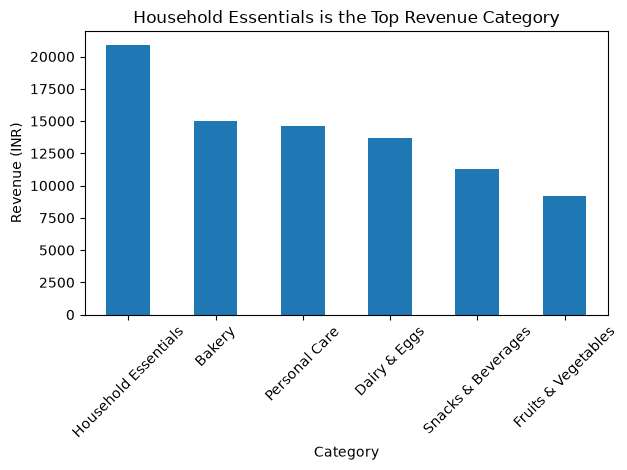

In [17]:
cat.plot(kind="bar")

plt.title("Household Essentials is the Top Revenue Category")
plt.xlabel("Category")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

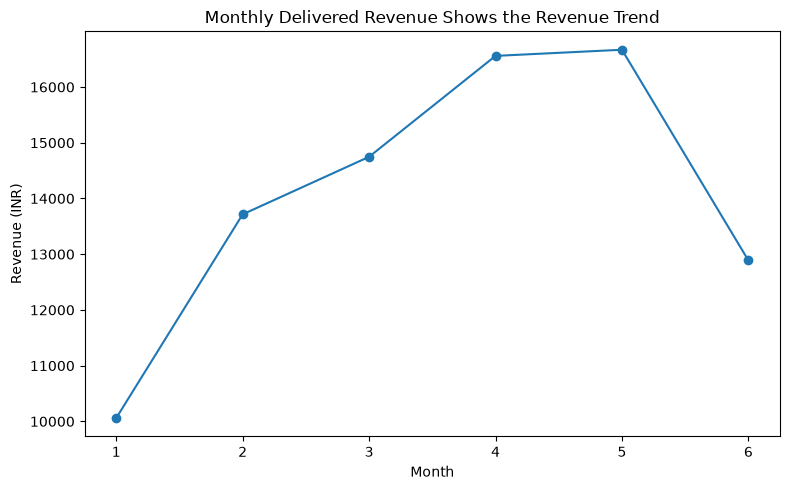

In [18]:
monthly = df[
    (df["status"] == "Delivered") &
    (df["amount_inr"].notna())
].groupby("month")["amount_inr"].sum()

plt.figure(figsize=(8, 5))

monthly.plot(kind="line", marker="o")

plt.title("Monthly Delivered Revenue Shows the Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")

plt.tight_layout()
plt.show()

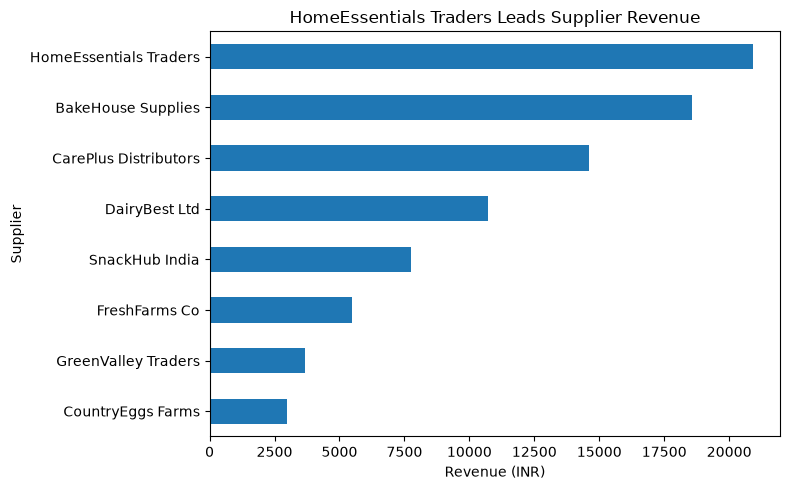

In [19]:
top_sup = sup.head(10).sort_values()

plt.figure(figsize=(8, 5))

top_sup.plot(kind="barh")

plt.title("HomeEssentials Traders Leads Supplier Revenue")
plt.xlabel("Revenue (INR)")
plt.ylabel("Supplier")

plt.tight_layout()
plt.show()

In [20]:
cat

category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr, dtype: float64

In [21]:
monthly

month
1    10059.5
2    13715.0
3    14747.5
4    16558.5
5    16668.5
6    12888.0
Name: amount_inr, dtype: float64

In [22]:
sup

supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr, dtype: float64